In [1]:
from IPython.display import Image

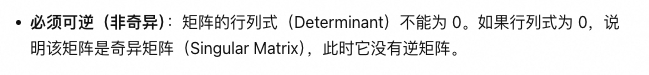

In [2]:
Image(filename='./Image/must_reverse.png')

#### <font color='red'>这个概念是理解矩阵求逆（以及为什么代码会报错）的核心</font>
- 简单来说，
  - <font color='blue'>“**可逆**”意味着信息没有丢失，</font>
  - <font color='blue'>而“**奇异**”意味着信息发生了不可恢复的坍塌。</font>
  
##### 什么是行列式（Determinant）？
要理解奇异矩阵，首先得**理解行列式**。
- 定义：**行列式是一个将方阵映射到一个标量（数值）的函数**，记作 det(A) 或 ∣A∣ 
- 几何意义（核心）：<font color='red'>行列式的绝对值代表了矩阵变换后的体积缩放比例</font>
  - 如果 det(A)=2 ，说明经过矩阵 A 变换后，物体的体积**变成了原来的 2 倍**。
  - 如果 det(A)=0.5 ，说明体积**缩小了一半**。
  
##### 什么是奇异矩阵（Singular Matrix）？
当行列式 det(A)=0 时，<font color='red'>这个矩阵就是奇异矩阵</font>

**几何直观：维度坍塌**
想象你手里有一个正方体（3D 空间）。

  - 非奇异矩阵：对这个正方体进行旋转、拉伸、剪切，它依然是一个立体的块状物，依然有体积。
  - 奇异矩阵：<font color='blue'>对这个正方体进行变换后，它被压扁了</font>
    - 它可能被压成了一张纸（2D 平面）。
    - 甚至被压成了一条线（1D 直线）。
    - 或者缩成了一个点（0D）。
    
**结论**：
- <font color='blue'>因为体积变成了 0，所以行列式为 0</font>。
  - 既然变成了低维物体，你就**无法通过逆变换把它还原回原来的正方体**（就像你没法把一张照片还原成真实的立体人像一样），所以它不可逆。



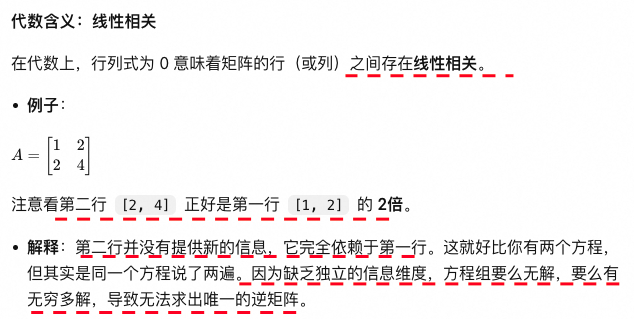

In [3]:
Image(filename='./Image/xxxg.png')

##### 为什么不可逆？（数学逻辑）

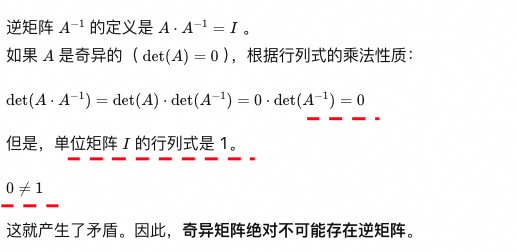

In [4]:
Image(filename='./Image/w_n_reverse.png')

##### 编程中的“坑”与解决方案
在使用 torch.inverse() 或 numpy.linalg.inv() 时，<font color='red'>这是最容易报错的地方。</font>

**现象**

<font color='red'>如果你尝试对一个奇异矩阵求逆，程序通常会抛出异常（如 RuntimeError: inverse_cuda: U(2,2) is zero, singular U）或者返回包含 inf (无穷大) 或 nan (非数字) 的结果。</font>

**现实世界的挑战：伪奇异**

在计算机浮点数运算中，很难遇到绝对的 0。你可能会遇到行列式极小（例如 $10^{−16}$）的情况。这在数值计算中被视为“**病态矩阵**”（Ill-conditioned），<font color='red'>求逆结果会极其不稳定，误差会被放大到天际</font>。
  
**解决方案：广义逆（Moore-Penrose Pseudoinverse）**

当矩阵奇异（或者不是方阵）时，我们通常不寻求完美的逆，而是寻求一个最优近似解。
- PyTorch: 使用 torch.linalg.pinv(A)
- NumPy: 使用 numpy.linalg.pinv(A)
pinv 使用 SVD（奇异值分解）技术，能够处理奇异矩阵，即使行列式为 0，它也能算出一个合理的“伪逆”矩阵，常用于线性回归等机器学习任务中。

##### 总结
- 可逆（非奇异） = 信息完整，维度保持，行列式≠0 ，可以完美还原。
- <font color='red'>不可逆（奇异） = 信息丢失，维度坍塌（压扁），行列式 =0 ，无法还原</font>
- 代码建议：**如果你不确定矩阵是否奇异，或者矩阵接近奇异，请优先使用 torch.linalg.pinv 代替 torch.inverse。**

# 逆矩阵的意义

在标准的大语言模型（Transformer）训练和推理中，几乎不会直接计算逆矩阵。
- 原因很直接：对于 d×d  的矩阵，求逆的计算复杂度是 O($d^3$) ，且数值稳定性差—
  - 而 LLM 的隐藏维度通常是 4096、8192 甚至更大，**显式求逆既不现实也无必要**。
 
在大模型（LLM）中，计算逆矩阵的意义主要体现在
- **优化算法的加速**
- **新型注意力机制的实现**
- 以及**数学推理能力的验证**三个方面。

由于大模型参数量巨大，<font color='red'>直接对全局矩阵求逆在计算上通常是不可行的</font>，因此<font color='blue'>这里的“逆矩阵”更多是指针对特定子结构的近似求逆，或是作为一种理论工具来改进模型架构。</font>

## 二阶优化器加速收敛
<font color='blue'>这是目前大模型训练中逆矩阵最“硬核”的实际应用</font>。
- 背景痛点：
  - 传统的优化器（如 Adam）是**一阶优化器**，只利用梯度（一阶导数）信息，相当于蒙眼下山，**只能感知坡度**。
  - 而**二阶优化器**利用海森矩阵（Hessian Matrix，二阶导数）来感知曲率，能更精准地找到下山方向。
  
- 逆矩阵的作用：
  - 牛顿法的核心公式是 $Δw=−H^{−1}∇L$ 。**这里必须计算海森矩阵的逆$ H^{−1}$**。<font color='red'>对于百亿参数模型，直接求逆是不可能的</font>。
- 解决方案：
  - 出现了如 Shampoo 等优化器。**它不直接求巨大的海森矩阵的逆**，<font color='blue'>而是将参数矩阵分解，计算较小的因子矩阵的逆（或近似逆）</font>。**这利用了逆矩阵来 preconditioner（预处理）梯度，使得模型收敛速度比 Adam 更快，尤其在训练后期效果显著。**


## 新型注意力机制与记忆更新
**在 Transformer 架构的改进研究中，逆矩阵被用来突破标准 Softmax 注意力的限制**
- 线性注意力与伪逆：
  - 标准的 Softmax 注意力是一种“凸组合”（**权重非负且和为 1**），只能混合信息。为了实现更复杂的逻辑（如“减去”某些记忆），研究者提出了基于伪逆的注意力机制。通过计算键矩阵的伪逆，模型可以实现非凸的组合，理论上表达能力更强。
  
- 高效写入机制：
  - 有研究提出了一种名为 SoftDelta 的机制，旨在优化长上下文建模。为了让模型在写入记忆时只存储“增量”而非重复信息，其数学推导涉及一个巨型矩阵的求逆运算。
    - **虽然直接计算很慢，但通过数学技巧绕过或近似这个逆矩阵，可以让模型在长文本任务上表现更稳定**。
  
## 数学推理能力的基准测试

随着大模型向“通用计算机”演进，**能否执行线性代数运算成为了衡量其智能程度的标尺**。
- In-Context Learning：
  - 研究发现，Transformer 可以通过上下文学习，**在不更新参数的情况下，学会执行矩阵求逆、特征值分解等数值计算任务**。
- 意义：
  - 这证明了神经网络不仅仅是统计拟合工具，它在内部可能真的学会了某种形式的“算法”。
  - <font color='red'>如果模型能准确输出一个矩阵的逆，说明它理解了线性变换的可逆性这一深层数学概念。</font>
  
## ⚠️ 关键限制与替代方案
虽然意义重大，**但在实际工程中，大家非常警惕直接求逆**：
- 数值不稳定性：
  - **逆矩阵对噪声极度敏感**。如果矩阵接近奇异（行列式接近 0），计算出的逆矩阵数值会爆炸，导致训练崩溃。
- 计算复杂度：
  - 求逆的复杂度是 $O(N^3) $。在大模型中，通常使用 Cholesky 分解、LU 分解或共轭梯度法来避免显式求逆，或者使用正则化技术来保证矩阵可逆。
  
## 为什么标准 LLM 不用逆矩阵？

| 原因         | 说明                                              |
| :--------- | :---------------------------------------------- |
| **计算成本**   | $O(d^3)$ 对 $d=4096$ 就是 680 亿次操作，一个层一次前向传播都承受不起  |
| **数值稳定性**  | 矩阵可能接近奇异（条件数很大），求逆会放大误差                         |
| **不需要**    | 反向传播用链式法则即可，无需显式求逆                              |
| **有更好的替代** | 线性方程组 $Ax=b$ 用迭代法（如共轭梯度）比求 $A^{-1}$ 再乘 $b$ 更快更稳 |
 为什么标准 LLM 不用逆矩阵？
 
## 一个更根本的视角
在深度学习中，"求逆"的思维被转化为"求解"的思维：

| 传统数学         | 深度学习实践           |
| :----------- | :--------------- |
| 计算 $A^{-1}$  | 用梯度下降迭代求解        |
| 解线性系统 $Ax=b$ | 用共轭梯度、GMRES 等迭代法 |
| 计算伪逆 $A^+$   | 用 SVD 截断或随机 SVD  |
